**Experiment E**

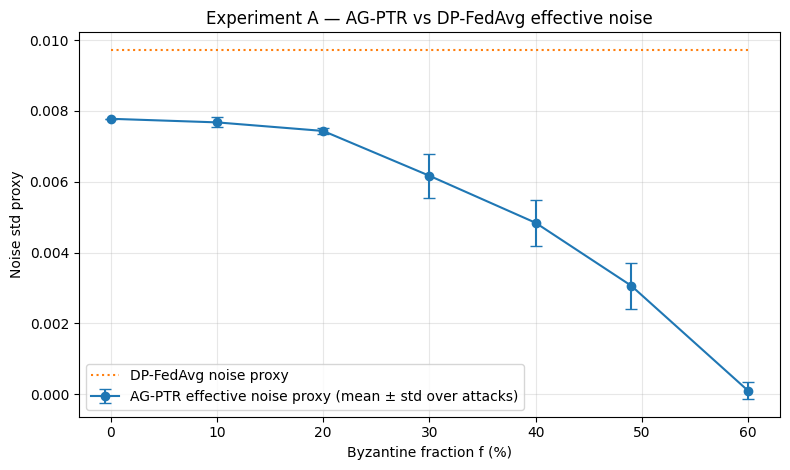

DP-FedAvg noise proxy = 0.009723217465539842
AG-PTR certified accepted-round noise proxy = 0.007863609780693477


,f,f_pct,noise_eff_mean,noise_eff_std
0,0.00,0.0,0.007776,0.000000
1,0.10,10.0,0.007675,0.000142
2,0.20,20.0,0.007433,0.000079
3,0.30,30.0,0.006167,0.000625
4,0.40,40.0,0.004839,0.000643
5,0.49,49.0,0.003063,0.000649
6,0.60,60.0,0.000098,0.000239


In [2]:
# Main figure — AG-PTR vs DP-FedAvg using effective noise proxy
# Input file: results.csv
# Dataset used: Fashion-MNIST-IID

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) Load results
# --------------------------------------------------
RESULTS_PATH = "results.csv"
if not os.path.exists(RESULTS_PATH):
    raise FileNotFoundError(f"Could not find {RESULTS_PATH}")

df_raw = pd.read_csv(RESULTS_PATH)

rename_map = {
    "Dataset": "dataset",
    "Attack": "attack",
    "Method": "method",
    "Percentage of Byzantine Cliets (%)": "f",
    "Accuracy": "acc",
    "Accept_Rate": "accept_rate",
}

missing = [c for c in rename_map if c not in df_raw.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}")

df = df_raw.rename(columns=rename_map).copy()

for col in ["dataset", "attack", "method"]:
    df[col] = df[col].astype(str).str.strip()

df["f"] = pd.to_numeric(df["f"], errors="coerce")
df["accept_rate"] = pd.to_numeric(df["accept_rate"], errors="coerce")

# --------------------------------------------------
# 2) Filter to original Experiment A dataset + AG-PTR
# --------------------------------------------------
DATASET_NAME = "Fashion-MNIST-IID"

ag = df[
    (df["dataset"] == DATASET_NAME) &
    (df["method"] == "AG-PTR")
].copy()

if len(ag) == 0:
    raise ValueError(f"No AG-PTR rows found for dataset={DATASET_NAME!r}")

# --------------------------------------------------
# 3) Constants from original Experiment A
# --------------------------------------------------
M = 100
C = 1.0
rho = 0.4
tau = 50

sigma_dp  = 0.9723217465539842
sigma_rel = 0.9829512225866845

# DP-FedAvg constant noise proxy
dp_noise = sigma_dp * C / M

# AG-PTR certified accepted-round noise proxy
ag_noise_cert = sigma_rel * rho / tau

# AG-PTR effective noise proxy over all rounds
ag["accept_rate_filled"] = ag["accept_rate"].fillna(0.0)
ag["ag_noise_eff"] = np.sqrt(np.clip(ag["accept_rate_filled"].values, 1e-12, 1.0)) * ag_noise_cert
ag["f_pct"] = ag["f"] * 100.0

# Aggregate over attacks: mean ± std
agg = (
    ag.groupby("f", as_index=False)
      .agg(
          f_pct=("f_pct", "first"),
          noise_eff_mean=("ag_noise_eff", "mean"),
          noise_eff_std=("ag_noise_eff", "std"),
      )
      .sort_values("f")
      .reset_index(drop=True)
)

# --------------------------------------------------
# 4) Plot
# --------------------------------------------------
x = agg["f_pct"].values
x0, x1 = x.min(), x.max()

plt.figure(figsize=(8, 4.8))
plt.errorbar(
    x,
    agg["noise_eff_mean"],
    yerr=agg["noise_eff_std"],
    marker="o",
    capsize=4,
    label="AG-PTR effective noise proxy (mean ± std over attacks)"
)
plt.plot(
    [x0, x1],
    [dp_noise, dp_noise],
    linestyle=":",
    label="DP-FedAvg noise proxy"
)

plt.xlabel("Byzantine fraction f (%)")
plt.ylabel("Noise std proxy")
plt.title("Experiment A — AG-PTR vs DP-FedAvg effective noise")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("DP-FedAvg noise proxy =", dp_noise)
print("AG-PTR certified accepted-round noise proxy =", ag_noise_cert)
display(agg)